In [1]:
# Install tutorial-specific dependencies (e.g., matplotlib for plotting)
%pip install matplotlib seaborn kagglehub --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import kagglehub
import numpy as np 
import pandas as pd
import os
from pyhctsa.calculator import FeatureCalculator
from scipy.signal import filtfilt, butter
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
import seaborn as sns

# ✨ Tutorial: Bonn EEG (end-to-end pyhctsa workflow)

This tutorial provides a hands-on walkthrough of the standard pyhctsa pipeline using data from the Bonn EEG dataset. We will move through the entire research cycle—starting with raw time-series data and ending with interpreted classification results.

*What You Will Learn*

The workflow is divided into four key phases:
1. Data Preparation: Structuring your time-series data and associated metadata into the required pyhctsa format.

2. Feature Extraction: Leveraging the massive feature library to compute thousands of properties for each time series.

3. Data Processing & Cleaning: Handling missing values, normalizing features, and preparing the resulting feature matrix for analysis.

4. Analysis & Visualization: Implementing classification algorithms to distinguish between data classes and using built-in visualization tools to interpret which features drive those differences.

## ⬇️ (1) Download the Bonn EEG Dataset

Download the Bonn EEG dataset directly from kaggle 

- EEG recordings from healthy individuals and patients with epilepsy
- Five distinct classes: A, B, C, D and E
- Each class has 100 single-channel EEG segments, with each segment comprising 23.6 seconds of EEG data, sampled at 173.61 Hz, yielding a length 4096 sample time series

A = Z, B = O, C = N, D = F, E = S

- A/Z = eyes open healthy (eyesOpen)
- B/O = eyes closed healthy (eyesClosed)
- C/N = seizure free interval for epileptic patient (hippocampus)
- D/F = seizure free interval epileptic patient, non-seizure epileptogenic zone (epileptogenic)
- E/S = During seizure epileptic patient (seizure)

In [2]:
path = kagglehub.dataset_download("quands/eeg-dataset") # download from kagglehub
print(os.listdir(os.path.join(path, 'Dataset'))) # display the subfolders

['N', 'Z', 'S', 'F', 'O']


Define the class mappings

In [3]:
mappings = {'Z': 'eyesOpen', 'N': 'hippocampus', 'F': 'epileptogenic', 'S': 'seizure', 'O': 'eyesClosed'}

## 🗳 (2) Pre-process the EEG recordings

Pre-filter with a 40Hz low pass

In [4]:
def unpack_subfolder(base_path : str, which_folder : str) -> pd.DataFrame:
    cutoff_freq = 40.0 # 40 Hz
    fs = 173.61 # sample rate in Hz
    order = 4 # 4th order butterworth filter
    nyq = 0.5 * fs
    normal_cutoff = cutoff_freq/nyq
    b, a = butter(order, normal_cutoff, btype='lowpass')
    if which_folder.lower() in ['n', 'z', 's', 'f', 'o']:
        label = mappings[which_folder.upper()]
        path = os.path.join(base_path, 'Dataset', which_folder)
        assert(os.path.exists(path))
        # check number of files
        subfiles = os.listdir(path)
        num_subfiles = len(subfiles)
        if num_subfiles != 100:
            print(f'More files than expected. Expected 100, got {num_subfiles}')
        all_series = []
        for subfile in subfiles:
            data = np.loadtxt(os.path.join(path, subfile))
            filtered_data = filtfilt(b, a, data)
            all_series.append(filtered_data)
        df = pd.DataFrame(all_series)
        df['label'] = label
    else:
        raise ValueError(f"Unknown folder: {which_folder}")
    return df

Concatenate all time-series instances into a single dataframe

In [5]:
df_series = pd.concat([unpack_subfolder(path, c) for c in ['N', 'Z', 'S', 'F', 'O']])

In [6]:
df_series.head(3)

,0,1,2,3,4,5,6,7,8,9,...,4088,4089,4090,4091,4092,4093,4094,4095,4096,label
0,-76.002880,-8.160361,36.130147,37.625116,0.235783,-41.989949,-54.718865,-38.386317,-20.373990,-17.291749,...,180.432287,164.583116,150.705251,157.809372,194.080194,235.464085,228.103199,127.476462,-51.043101,hippocampus
1,34.000406,31.416358,27.038342,21.346209,15.747189,10.304919,4.426019,-1.259340,-5.333748,-7.425735,...,-22.703815,-16.919187,-13.739674,-12.329390,-8.005106,1.240274,7.273179,-2.612481,-28.999855,hippocampus
2,-56.990550,-71.547664,-75.119898,-67.728569,-58.999405,-56.182465,-56.529083,-53.060212,-44.914053,-38.376826,...,-70.041801,-60.266899,-43.302333,-26.943180,-24.632308,-40.924329,-56.324522,-40.254580,10.991437,hippocampus


Plot first example from each class:

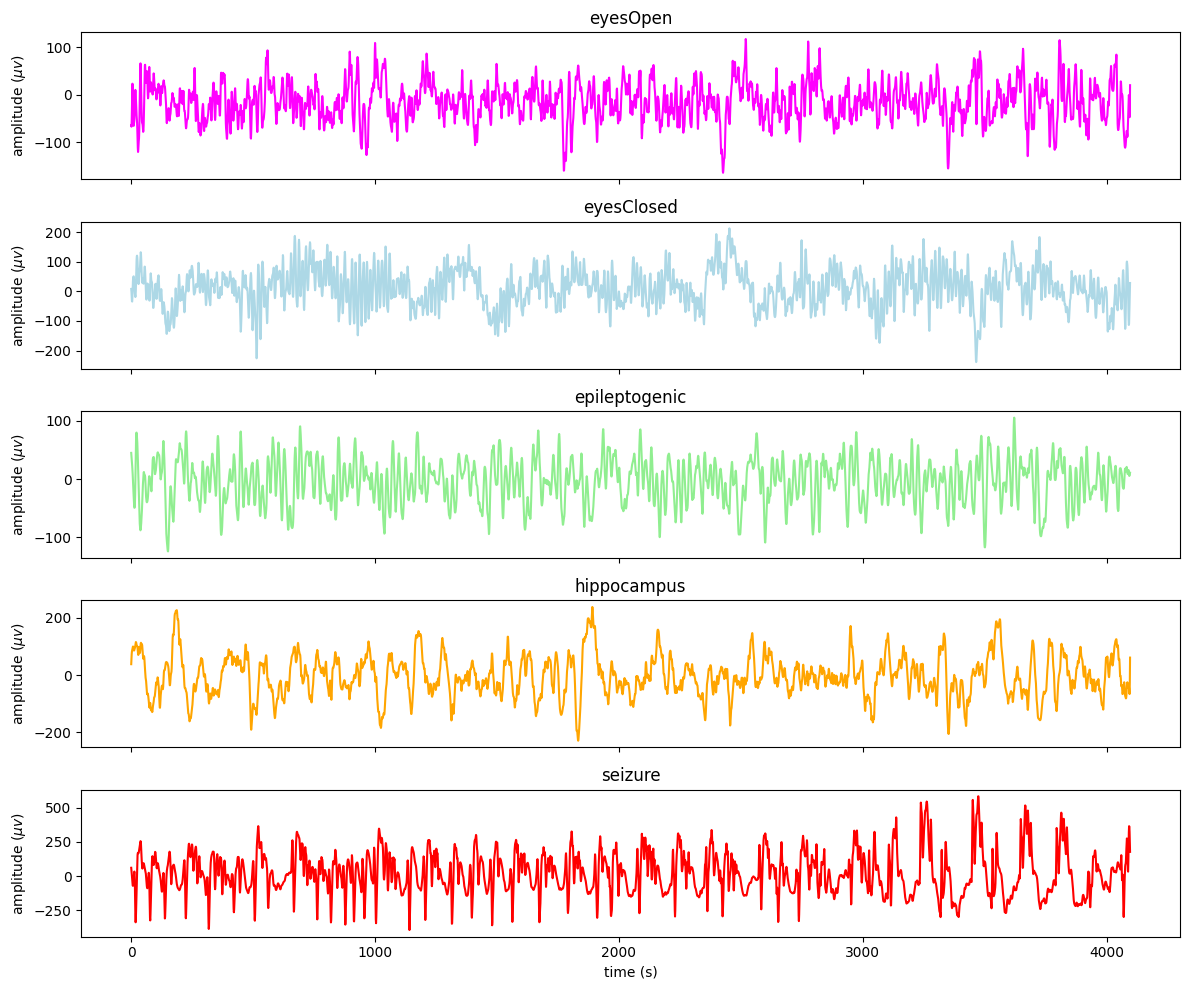

In [7]:
fs = 173.61
fix = False
t = np.arange(df_series.drop(columns=['label']).shape[1])/fs
fig, ax = plt.subplots(5, 1, sharex=True, figsize=(12, 10))
df_series[df_series['label'] == 'eyesOpen'].drop(columns=['label']).iloc[0 if fix else np.random.randint(0, 99)].plot(x=t, ax=ax[0], title="eyesOpen", c='magenta')
df_series[df_series['label'] == 'eyesClosed'].drop(columns=['label']).iloc[0 if fix else np.random.randint(0, 99)].plot(x=t, ax=ax[1], title="eyesClosed", c='lightblue')
df_series[df_series['label'] == 'epileptogenic'].drop(columns=['label']).iloc[0 if fix else np.random.randint(0, 99)].plot(x=t, ax=ax[2], title="epileptogenic", c='lightgreen')
df_series[df_series['label'] == 'hippocampus'].drop(columns=['label']).iloc[0 if fix else np.random.randint(0, 99)].plot(x=t, ax=ax[3], title="hippocampus", c='orange')
df_series[df_series['label'] == 'seizure'].drop(columns=['label']).iloc[0 if fix else np.random.randint(0, 99)].plot(x=t, ax=ax[4], title="seizure", c='red')
plt.xlabel("time (s)")
ax[0].set_ylabel(rf"amplitude ($\mu v$)")
ax[1].set_ylabel(rf"amplitude ($\mu v$)")
ax[2].set_ylabel(rf"amplitude ($\mu v$)")
ax[3].set_ylabel(rf"amplitude ($\mu v$)")
ax[4].set_ylabel(rf"amplitude ($\mu v$)")
plt.tight_layout()

## ⚙️ (3) Instantiate a calculator in _pyhctsa_

While you can run the calculator with the full _hctsa_ feature set, for the sake of brevity, we will use a custom yaml file with a selected subset of 110 "fast" feature functions:

In [8]:
calc = FeatureCalculator()

Loaded 773 master operations.


In [9]:
bonn_eeg = df_series

In [10]:
data_df = bonn_eeg.drop(columns=['label']).to_numpy() # drop the labels column for computing features on the time-series data

To ensure everything is working as expected, we will first run the calculator on the first instance/time-series of the data frame

In [11]:
res = calc.extract(data_df[0, :])

Evaluating 773 partialed functions. Strap in!...
Feature extraction completed in 4.727 seconds.


In [12]:
res

,hrv_classic.pnn5,hrv_classic.pnn10,hrv_classic.pnn20,hrv_classic.pnn30,hrv_classic.pnn40,hrv_classic.lfhf,hrv_classic.vlf,hrv_classic.lf,hrv_classic.hf,hrv_classic.tri,...,embed_pca_ac_3.top2,embed_pca_ac_3.nto50,embed_pca_ac_3.nto60,embed_pca_ac_3.nto70,embed_pca_ac_3.nto80,embed_pca_ac_3.nto90,embed_pca_ac_3.fb05,embed_pca_ac_3.fb02,embed_pca_ac_3.fb01,embed_pca_ac_3.fb001
instance,,,,,,,,,,,,,,,,,,,,,
ts_1,0.988037,0.975098,0.943359,0.915039,0.887207,1.438589,16.373641,38.574764,26.814297,3.080451,...,0.71099,1,1,1,2,2,0,4,4,4


Now that everything is working, let's scale up to the full dataset:

In [13]:
res = calc.extract(data_df)

Evaluating 773 partialed functions. Strap in!...


KeyboardInterrupt: 

#### [OPTIONAL] (3.5)

Time-series feature extraction is computationally intensive. To speed up processing, pyhctsa allows you to distribute the workload across multiple CPU cores on your local machine using the `LocalDistributor`:

In [14]:
from pyhctsa.distribute import LocalDistributor

In [15]:
# create a LocalDistributor
dist = LocalDistributor(n_workers=6) # set to the number of physical cores available on your local machine...

In [16]:
res = calc.extract(data_df, distributor=dist)

Output()

Evaluating 773 partialed functions. Strap in!...


The data contains negative values, but Exponential is a positive-only distribution.
The data are not positive, but Log-Normal is a positive-only distribution.
The data contains negative values, but Exponential is a positive-only distribution.
The data are not positive, but Log-Normal is a positive-only distribution.
The data contains negative values, but Exponential is a positive-only distribution.
The data are not positive, but Log-Normal is a positive-only distribution.
The data contains negative values, but Exponential is a positive-only distribution.
The data are not positive, but Log-Normal is a positive-only distribution.
The data contains negative values, but Exponential is a positive-only distribution.
The data are not positive, but Log-Normal is a positive-only distribution.


The data contains negative values, but Exponential is a positive-only distribution.
The data are not positive, but Log-Normal is a positive-only distribution.


The data contains negative values, but Exponential is a positive-only distribution.
The data are not positive, but Log-Normal is a positive-only distribution.
The data contains negative values, but Exponential is a positive-only distribution.
The data are not positive, but Log-Normal is a positive-only distribution.
The data contains negative values, but Exponential is a positive-only distribution.
The data are not positive, but Log-Normal is a positive-only distribution.


...

The data contains negative values, but Exponential is a positive-only distribution.
The data are not positive, but Log-Normal is a positive-only distribution.


The data contains negative values, but Exponential is a positive-only distribution.
The data are not positive, but Log-Normal is a positive-only distribution.


The data contains negative values, but Exponential is a positive-only distribution.
The data are not positive, but Log-Normal is a positive-only distribution.


The data contains negative values, but Exponential is a positive-only distribution.
The data are not positive, but Log-Normal is a positive-only distribution.


Feature extraction completed in 512.420 seconds.


Here we can see that by utilising parallel computing, we can reduce our feature extraction time by a factor of ~4.

### [OPTIONAL] Load results from the full feature set

If you wish to access the results from the full hctsa feature set, but do not want to run the full feature set locally due to time contraints, you can download and import the pre-computed results from https://doi.org/10.6084/m9.figshare.31290259

In [39]:
LOAD_PRECALCULATED_RESULTS = True # set to true to load the results
if LOAD_PRECALCULATED_RESULTS:
    res = pd.read_pickle("./bonn_eeg_results.pkl") # point to the path where the downloaded results exist

FileNotFoundError: [Errno 2] No such file or directory: './bonn_eeg_results.pkl'

In [51]:
res.head(5)

,hrv_classic.pnn5,hrv_classic.pnn10,hrv_classic.pnn20,hrv_classic.pnn30,hrv_classic.pnn40,hrv_classic.lfhf,hrv_classic.vlf,hrv_classic.lf,hrv_classic.hf,hrv_classic.tri,...,embed_pca_ac_3.nto50,embed_pca_ac_3.nto60,embed_pca_ac_3.nto70,embed_pca_ac_3.nto80,embed_pca_ac_3.nto90,embed_pca_ac_3.fb05,embed_pca_ac_3.fb02,embed_pca_ac_3.fb01,embed_pca_ac_3.fb001,multi_scale_entropy_1_to_10_2_0p15_rescale_tau.out
instance,,,,,,,,,,,,,,,,,,,,,
ts_1,0.988037,0.975098,0.943359,0.915039,0.887207,1.438589,16.373641,38.574764,26.814297,3.080451,...,1,1,1,2,2,0,4,4,4,NaN
ts_2,0.979736,0.959473,0.916504,0.875244,0.831299,1.910163,16.994118,50.579037,26.478908,2.559026,...,1,1,1,2,2,0,4,4,4,NaN
ts_3,0.979492,0.960938,0.929443,0.891602,0.852295,2.321853,26.072435,47.009691,20.246629,3.590710,...,1,1,2,2,2,0,4,4,4,NaN
ts_4,0.976807,0.953125,0.906738,0.856689,0.813721,3.314088,47.505651,36.356375,10.970250,3.584427,...,1,1,2,2,2,0,4,4,4,NaN
ts_5,0.979492,0.957764,0.914795,0.870605,0.833008,2.491926,17.374024,55.482169,22.264773,2.873072,...,1,1,1,2,2,0,4,4,4,NaN


## (4) Clean the results table

Not all features returned by _pyhctsa_ will be well-behaved on every dataset. To perform downstream analyses such as classification, we must first filter out special-valued features and NaNs: 

In [52]:
res_clean = (
    res.replace([np.inf, -np.inf], np.nan)
      .dropna(axis=1)
)

In [53]:
res_filtered = res_clean.dropna(axis=1)

Filter out non-numeric

In [54]:
res_num = res_filtered.apply(pd.to_numeric, errors="coerce")
good_cols = res_num.notna().eq(res.notna()).all(axis=0)
res_num_strict = res_num.loc[:, good_cols]

Filter out zero variance (constant) columns

In [55]:
zero_var_cols = res_num_strict.columns[res_num_strict.var(axis=0, skipna=True) == 0]
zero_var_cols

Index(['add_noise_1_quantiles_10.pcrossmean', 'add_noise_1_even_10.pcrossmean',
       'add_noise_1_std1_10.pcrossmean', 'add_noise_1_gaussian.pdec',
       'add_noise_1_gaussian.pcrossmean', 'add_noise_1_kraskov1_4.pcrossmean',
       'translate_shape_circle_1p5_pts.max',
       'translate_shape_circle_1p5_pts.mode',
       'translate_shape_circle_2p5_pts.max',
       'translate_shape_circle_2p5_pts.mode',
       ...
       'walker_prop_0p1.res_runstest', 'walker_prop_0p5.res_runstest',
       'walker_prop_0p9.res_runstest', 'walker_prop_1p1.res_runstest',
       'walker_biasprop_0p5_0p1.res_runstest',
       'walker_biasprop_0p1_0p5.res_runstest',
       'walker_momentum_5.res_runstest', 'embed_pca_mi_10.fb05',
       'embed_pca_ac_3.nto60', 'embed_pca_ac_3.fb001'],
      dtype='str', length=107)

In [56]:
good_features_df = res_num_strict.drop(columns=zero_var_cols)

In [57]:
good_features_df

,hrv_classic.pnn5,hrv_classic.pnn10,hrv_classic.pnn20,hrv_classic.pnn30,hrv_classic.pnn40,hrv_classic.lfhf,hrv_classic.vlf,hrv_classic.lf,hrv_classic.hf,hrv_classic.tri,...,embed_pca_ac_3.min,embed_pca_ac_3.max,embed_pca_ac_3.top2,embed_pca_ac_3.nto50,embed_pca_ac_3.nto70,embed_pca_ac_3.nto80,embed_pca_ac_3.nto90,embed_pca_ac_3.fb05,embed_pca_ac_3.fb02,embed_pca_ac_3.fb01
instance,,,,,,,,,,,,,,,,,,,,,
ts_1,0.988037,0.975098,0.943359,0.915039,0.887207,1.438589,16.373641,38.574764,26.814297,3.080451,...,0.289010,0.380008,0.710990,1,1,2,2,0,4,4
ts_2,0.979736,0.959473,0.916504,0.875244,0.831299,1.910163,16.994118,50.579037,26.478908,2.559026,...,0.286277,0.380164,0.713723,1,1,2,2,0,4,4
ts_3,0.979492,0.960938,0.929443,0.891602,0.852295,2.321853,26.072435,47.009691,20.246629,3.590710,...,0.313344,0.352109,0.686656,1,2,2,2,0,4,4
ts_4,0.976807,0.953125,0.906738,0.856689,0.813721,3.314088,47.505651,36.356375,10.970250,3.584427,...,0.323292,0.343809,0.676708,1,2,2,2,0,4,4
ts_5,0.979492,0.957764,0.914795,0.870605,0.833008,2.491926,17.374024,55.482169,22.264773,2.873072,...,0.286468,0.379660,0.713532,1,1,2,2,0,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ts_496,0.984375,0.970215,0.944824,0.917725,0.889648,0.336630,13.870277,18.356541,54.530277,3.028086,...,0.223408,0.447544,0.776592,1,1,2,2,0,4,4
ts_497,0.989990,0.981934,0.962158,0.946045,0.925537,0.197599,2.498134,6.366314,32.218319,4.028515,...,0.118170,0.475126,0.881830,1,1,1,2,0,2,4
ts_498,0.987549,0.976074,0.952881,0.928955,0.905029,0.297679,8.875599,16.243974,54.568739,3.149116,...,0.254939,0.380331,0.745061,1,1,2,2,0,4,4


Normalise features to standardise their respective scales

In [58]:
good_features_df_N = MinMaxScaler().fit_transform(good_features_df)

## 🖥 (5) Visualisation

To get a sense of how the _pyhctsa_ features capture dimensions along which different types of dynamics can be distinguished, we can use linear dimensionality reduction methods such as PCA, or non-linear methods such as t-SNE to visualise how time-series instances cluster or separate:

In [59]:
pc_fit = PCA(n_components=2).fit(good_features_df_N)
pc = pc_fit.transform(good_features_df_N)
pc_df = pd.DataFrame(pc, columns=['PC1', 'PC2'])
pc_df['label'] = df_series['label'].to_numpy()

In [60]:
tsne_fit = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(good_features_df_N)
tsne_df = pd.DataFrame(tsne_fit, columns=['tSNE1', 'tSNE2'])
tsne_df['label'] = df_series['label'].to_numpy()

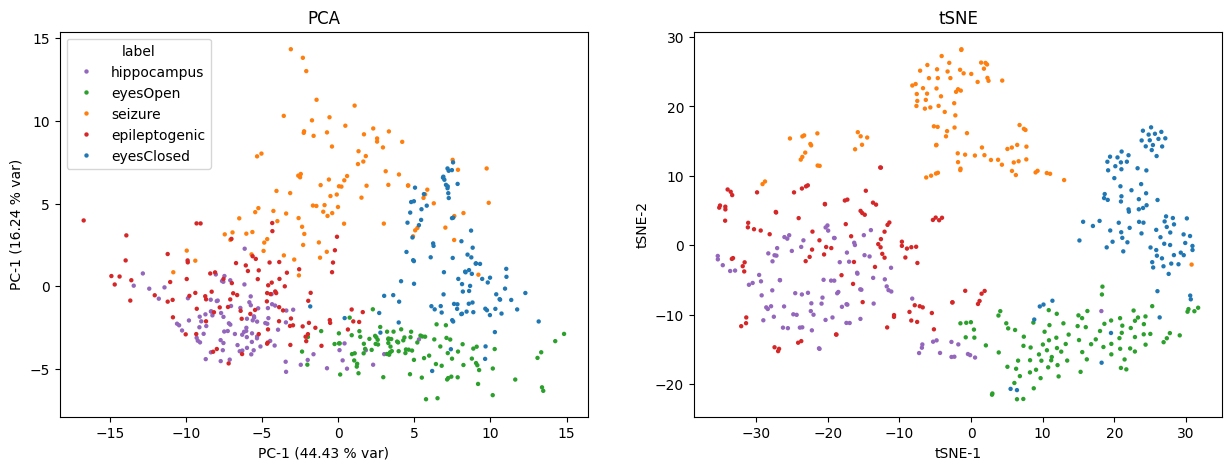

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
palette = {
    "epileptogenic": "#d62728", 
    "eyesClosed":    "#1f77b4", 
    "eyesOpen":      "#2ca02c",  
    "hippocampus":   "#9467bd",  
    "seizure":       "#ff7f0e",
}
#sns.kdeplot(data=pc_df, x='PC1', y='PC2', hue='label', alpha=0.4)
sns.scatterplot(data=pc_df, x='PC1', y='PC2', hue='label', palette=palette, ax=ax[0], s=10, linewidth=0)
ax[0].set_xlabel(f'PC-1 ({np.round(pc_fit.explained_variance_[0], 2)} % var)')
ax[0].set_ylabel(f'PC-1 ({np.round(pc_fit.explained_variance_[1], 2)} % var)')
ax[0].set_title("PCA")

sns.scatterplot(data=tsne_df, x='tSNE1', y='tSNE2', hue='label', palette=palette, ax=ax[1], s=10, linewidth=0)
ax[1].set_title('tSNE')
ax[1].set_xlabel('tSNE-1')
ax[1].set_ylabel('tSNE-2')
ax[1].legend().remove()
plt.show()

## Seizure vs Eyes Open

In [62]:
subset_df = pc_df[(pc_df['label'] == 'eyesOpen') | (pc_df['label'] == 'seizure')]

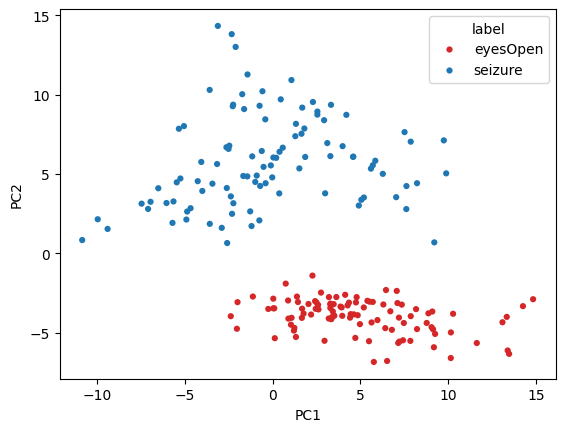

In [63]:
palette2 = {
    "eyesOpen":      "#d62728",  
    "seizure":       "#1f77b4",
}
sns.scatterplot(data=subset_df, x='PC1', y='PC2', hue='label', palette=palette2, s=20, linewidth=0)
plt.show()

## 📂 Classification Problem

Let's now try to classify between the five groups using a simple linear SVM classifier. Here we will use 10-fold cross validation with a linear SVM and default parameters

In [64]:
# create source dataset
df_source = good_features_df
df_source['label'] = df_series['label'].to_numpy()
X = df_source.drop(columns=['label']).to_numpy()
y = df_source['label'].to_numpy() # classes 

In [65]:
skf = StratifiedKFold(n_splits=10, random_state=0, shuffle=True)

In [69]:
per_fold_accuracy = {}
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"Fold {i}:")
    # construct training set and test set
    X_train, y_train = X[train_index, :], y[train_index]
    X_test, y_test = X[test_index, :], y[test_index]
    # fit the scaler to the training set
    mm = MinMaxScaler().fit(X_train)
    X_train_N = mm.transform(X_train)
    X_test_N = mm.transform(X_test)
    # fit the linear SVM
    sv = LinearSVC(max_iter=10_000).fit(X_train_N, y_train)
    # because classes are balance, acc is automatically the bal acc
    score = sv.score(X_test_N, y_test)
    print(f'Classifcation accuracy: {score}')
    per_fold_accuracy[f'fold {i+1}'] = score
# print overall mean accuracy across the 10 folds
mean_fold_acc = np.mean([per_fold_accuracy[v] for v in per_fold_accuracy])
print(f'Mean (across folds) accuracy (5-class) using 10-fold svm_linear classification: {mean_fold_acc*100}%')

Fold 0:
Classifcation accuracy: 0.92
Fold 1:
Classifcation accuracy: 0.92
Fold 2:
Classifcation accuracy: 0.98
Fold 3:
Classifcation accuracy: 0.92
Fold 4:
Classifcation accuracy: 0.98
Fold 5:
Classifcation accuracy: 0.9
Fold 6:
Classifcation accuracy: 0.96
Fold 7:
Classifcation accuracy: 0.94
Fold 8:
Classifcation accuracy: 0.88
Fold 9:
Classifcation accuracy: 0.94
Mean (across folds) accuracy (5-class) using 10-fold svm_linear classification: 93.39999999999999%
